# ML Model Evaluations: Taylor Diagram & Wasserstein-Taylor Diagram

- Load model predictions.
- Plot basic Taylor Diagram.
- Calculate an plot Wasserstein-Taylor Diagram.

**Dongwei & Hungjui – 20260610**


In [1]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import geocat.viz as gv
import pandas as pd

from scipy import stats
from scipy.optimize import brentq


C:\Users\Dongwei Chen\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\Dongwei Chen\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\Dongwei Chen\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


***
## Load data:

In [2]:
df_load = pd.read_parquet("C:\\Users\\Dongwei Chen\\Desktop\\W_Taylor\\caig_model_eval_25N_107W.parquet")


## Filter:
mask = (df_load['time'].dt.month >= 5) & (df_load['time'].dt.month <= 9) & (df_load['CONUS404'] != 0)
df = df_load[mask]

df

,time,CONUS404,MLP,EBM,EBMregion,LR
3646,2022-06-01 22:00:00,2.040816,0.009511,1.268368,0.306640,1.577847
3655,2022-06-02 07:00:00,2.040816,0.009511,4.408128,2.156787,1.811706
3656,2022-06-02 08:00:00,2.040816,0.047422,3.007746,1.951376,1.890444
3663,2022-06-02 15:00:00,4.081633,0.283169,6.494184,1.622204,1.572745
3665,2022-06-02 17:00:00,2.040816,0.351532,3.202803,1.088160,1.275279
...,...,...,...,...,...,...
6417,2022-09-25 09:00:00,2.040816,1.332520,-0.872926,0.733324,2.366891
6481,2022-09-28 01:00:00,4.081633,3.837557,4.371834,1.928928,2.771852
6506,2022-09-29 02:00:00,73.469388,8.117660,9.836617,5.001770,5.474789
6507,2022-09-29 03:00:00,53.061224,16.015110,7.802735,3.508444,3.544663


In [3]:
obs = df['CONUS404']


Corr = []
prediction_std =[]

####MLP
corr = np.corrcoef(obs, df['MLP'])[0,1]
fitted_std = np.std(df['MLP'], ddof=0)
Corr.append(corr)
prediction_std.append(fitted_std)

######EBM
corr = np.corrcoef(obs, df['EBM'])[0,1]
fitted_std = np.std(df['EBM'], ddof=0)
Corr.append(corr)
prediction_std.append(fitted_std)


######EBMregion
corr = np.corrcoef(obs, df['EBMregion'])[0,1]
fitted_std = np.std(df['EBMregion'], ddof=0)
Corr.append(corr)
prediction_std.append(fitted_std)

######LR
corr = np.corrcoef(obs, df['LR'])[0,1]
fitted_std = np.std(df['LR'], ddof=0)
Corr.append(corr)
prediction_std.append(fitted_std)


######Reference
Corr.append(1)
prediction_std.append(np.std(obs, ddof=0))
print(Corr)
print(prediction_std)

[0.7175343074692309, 0.5443462712124172, 0.4513779632117431, 0.816673419854492, 1]
[15.356207847595215, 5.459965800069225, 8.836203388851107, 1.6480645778721186, 22.72008024215891]


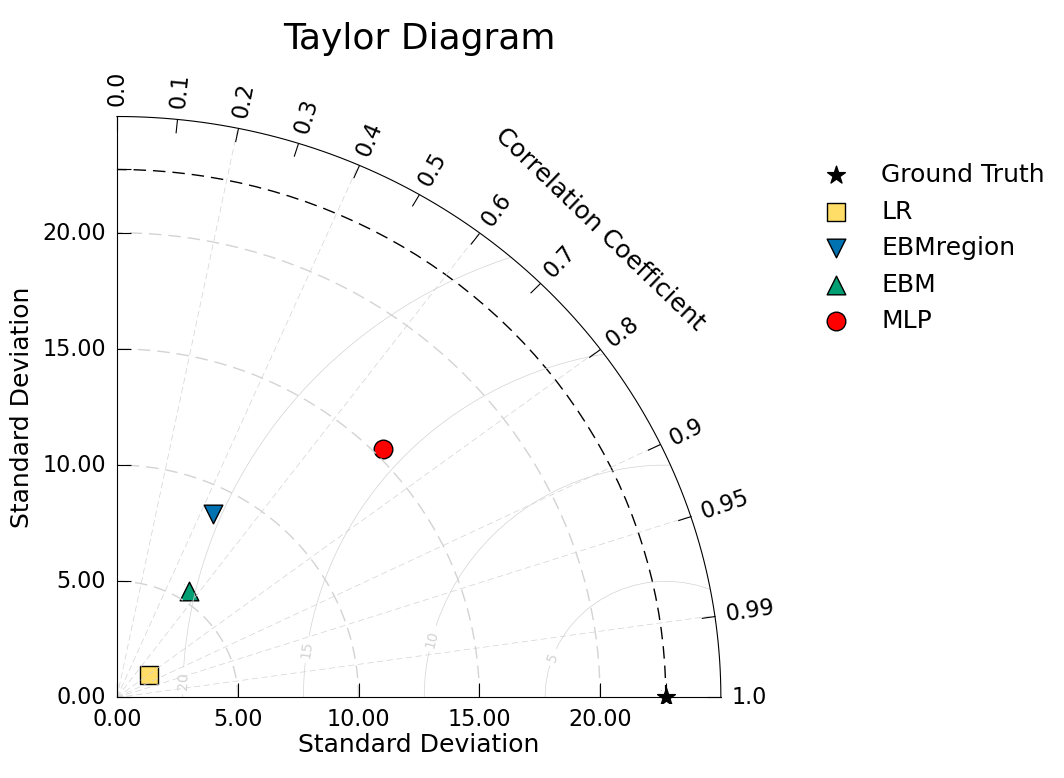

In [4]:
color_1 = (255/255, 0/255, 0/255)     # Pure Red
color_2  = (  0/255, 158/255, 115/255)   # Teal
color_3 = (0/255, 114/255, 178/255)   # Scientific Blue 
color_4  = (255/255, 221/255, 102/255)   # Soft Yellow
color_5  = (148/255,   0/255, 211/255)   # Dark Violet

color_6  = ( 86/255, 180/255, 233/255)   # Sky Blue
color_7  = (230/255, 159/255,   0/255)   # Orange Yellow
color_8 = (102/255, 51/255, 153/255)  # Deep Purple
color_9 = (139/255, 69/255, 19/255)   # Saddle Brown
color_10 = (180/255, 30/255, 90/255)   # Deep Rose

ground_truth_std = np.std(obs, ddof=0)

std_range_tuple = (0, 25)
# std_val_list = np.array([0, 0.5,1, 1.5,2,2.5,3,3.5,4,4.5,5,5.5, 6, 6.5, 7, 7.5, 8])
# std_val_list = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
std_val_list = np.arange(0, 25, 5, dtype=float)

## Create basic figure and Taylor Diagram instance:
fig = plt.figure(figsize=(8, 8))

taylor = gv.TaylorDiagram( refstd=ground_truth_std
                         , fig=fig
                         , label=''
                         , std_range=std_range_tuple
                         , std_level=np.insert(std_val_list
                         , np.searchsorted(std_val_list, ground_truth_std)
                         , ground_truth_std)
                         )
ax = plt.gca()

## Draw diagonal dashed lines from origin to correlation values
## Also enforces proper X-Y ratio
taylor.add_xgrid(np.array([0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99]))
taylor.add_ygrid(std_val_list)

spec_marker_size = 180

taylor.add_model_set( [prediction_std[0]]
                    , [Corr[0]]
                    , label='MLP'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color=color_1
                    , marker='o'
                    , facecolors=color_1
                    , edgecolors='k'
                    , linewidth=1
                    , s=spec_marker_size
                    )

taylor.add_model_set( [prediction_std[1]]
                    , [Corr[1]]
                    , label='EBM'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color=color_2
                    , marker='^'
                    , facecolors=color_2
                    , edgecolors='k'
                    , linewidth=1
                    # , linestyle='--'
                    , s=spec_marker_size
                    )

taylor.add_model_set( [prediction_std[2]]
                    , [Corr[2]]
                    , label='EBMregion'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color=color_3
                    , marker='v'
                    , facecolors=color_3
                    , edgecolors='k'
                    , linewidth=1
                    , s=spec_marker_size
                    )

taylor.add_model_set( [prediction_std[3]]
                    , [Corr[3]]
                    , label='LR'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color=color_4
                    , marker='s'
                    , facecolors=color_4
                    , edgecolors='k'
                    , linewidth=1 
                    , s=spec_marker_size
                    )

taylor.add_model_set( [ground_truth_std]
                    , [1]
                    , label='Ground Truth'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color='black'
                    , marker='*'
                    , facecolors='black'
                    , edgecolors='k'
                    , linewidth=1 
                    , s=spec_marker_size
                    )
#gv.util.set_axes_limits_and_ticks(ax, xlim=[0,2])

# taylor.add_model_name(['MLP', 'EBM', 'LR'], fontsize=16)

## Add figure title
plt.title("Taylor Diagram", size=26, pad=45)

taylor._ax.axis["left"].label.set_text("Standard Deviation")
taylor._ax.axis["right"].label.set_text("Standard Deviation")
taylor._ax.axis["top"].label.set_text("Correlation Coefficient")
taylor._ax.axis["left"].label.set_fontsize(18)
taylor._ax.axis["top"].label.set_fontsize(18)
taylor._ax.axis["right"].label.set_fontsize(18)


#taylor.add_legend(fontsize=10, loc='upper right')
taylor.add_legend(
    fontsize=18,
    loc='upper left',
    bbox_to_anchor=(1.05, 1)
)
## Add constant centered 2-Wasserstein difference contours.
crg = taylor.add_contours( levels=np.arange(0,25,5)
                         , colors='lightgrey'
                         , linewidths=0.5      
                         ).clabel()
# crg.clabel()

plt.savefig('fig4.png', dpi=300, bbox_inches='tight')
plt.savefig('fig4.pdf', dpi=300, bbox_inches='tight')


In [5]:
x = np.asarray(obs)
n = len(x)
u = (np.arange(1, n + 1) - 0.5) / n

x_sorted = np.sort(x)
x_centered = x_sorted - np.mean(x)


def centered_w2_distance(x_centered, q):
    q_sorted = np.sort(q)
    q_centered = q_sorted - np.mean(q)
    return np.sqrt(np.mean((x_centered - q_centered) ** 2))


def quantile_corr(x_centered, q):
    q_sorted = np.sort(q)
    q_centered = q_sorted - np.mean(q)
    return np.mean(x_centered * q_centered) / (
        np.std(x_centered, ddof=0) * np.std(q_centered, ddof=0)
    )


# --------------------------------------------------
# Compute centered W2 and quantile correlation
# --------------------------------------------------

#####MLP
Centered_W_2 = []
Quantile_Corr = []
prediction_std =[]
w2c = centered_w2_distance(x_centered, df['MLP'])
qcorr = quantile_corr(x_centered, df['MLP'])
fitted_std = np.std(df['MLP'], ddof=0)
Centered_W_2.append(w2c)
Quantile_Corr.append(qcorr)
prediction_std.append(fitted_std)

######EBM
w2c = centered_w2_distance(x_centered, df['EBM'])
qcorr = quantile_corr(x_centered, df['EBM'])
fitted_std = np.std(df['EBM'], ddof=0)
Centered_W_2.append(w2c)
Quantile_Corr.append(qcorr)
prediction_std.append(fitted_std)


######EBMregion
w2c = centered_w2_distance(x_centered, df['EBMregion'])
qcorr = quantile_corr(x_centered, df['EBMregion'])
fitted_std = np.std(df['EBMregion'], ddof=0)
Centered_W_2.append(w2c)
Quantile_Corr.append(qcorr)
prediction_std.append(fitted_std)

######LR
w2c = centered_w2_distance(x_centered, df['LR'])
qcorr = quantile_corr(x_centered, df['LR'])
fitted_std = np.std(df['LR'], ddof=0)
Centered_W_2.append(w2c)
Quantile_Corr.append(qcorr)
prediction_std.append(fitted_std)


######Reference
Centered_W_2.append(0)
Quantile_Corr.append(1)
prediction_std.append(np.std(obs, ddof=0))
print(Centered_W_2)
print(Quantile_Corr)
print(prediction_std)


# --------------------------------------------------
# Verify the law of cosines
#
# W_{2,c}^2
# =
# sigma_x^2 + sigma_q^2
# - 2 sigma_x sigma_q rho_q
# --------------------------------------------------

sigma_x = prediction_std[-1]

for i in range(len(prediction_std)):

    sigma_q = prediction_std[i]
    rho_q = Quantile_Corr[i]
    w2c = Centered_W_2[i]

    lhs = w2c**2

    rhs = (
        sigma_x**2
        + sigma_q**2
        - 2 * sigma_x * sigma_q * rho_q
    )

    print(f"LHS = W2_c^2      = {lhs:.10f}")
    print(f"RHS law cosine    = {rhs:.10f}")
    print(f"Difference        = {abs(lhs-rhs):.2e}")
    print("-" * 60)

[8.151405310665156, 17.764076691550738, 14.14328079379074, 21.178615116662378, 0]
[0.9824891667487878, 0.9288563175089202, 0.9818928514300586, 0.9398585230713675, 1]
[15.356207847595215, 5.459965800069225, 8.836203388851107, 1.6480645778721186, 22.72008024215891]
LHS = W2_c^2      = 66.4454085387
RHS law cosine    = 66.4454755700
Difference        = 6.70e-05
------------------------------------------------------------
LHS = W2_c^2      = 315.5624207033
RHS law cosine    = 315.5624207033
Difference        = 9.09e-13
------------------------------------------------------------
LHS = W2_c^2      = 200.0323916120
RHS law cosine    = 200.0323916120
Difference        = 7.96e-13
------------------------------------------------------------
LHS = W2_c^2      = 448.5337382597
RHS law cosine    = 448.5337382597
Difference        = 1.14e-12
------------------------------------------------------------
LHS = W2_c^2      = 0.0000000000
RHS law cosine    = 0.0000000000
Difference        = 0.00e+00
---

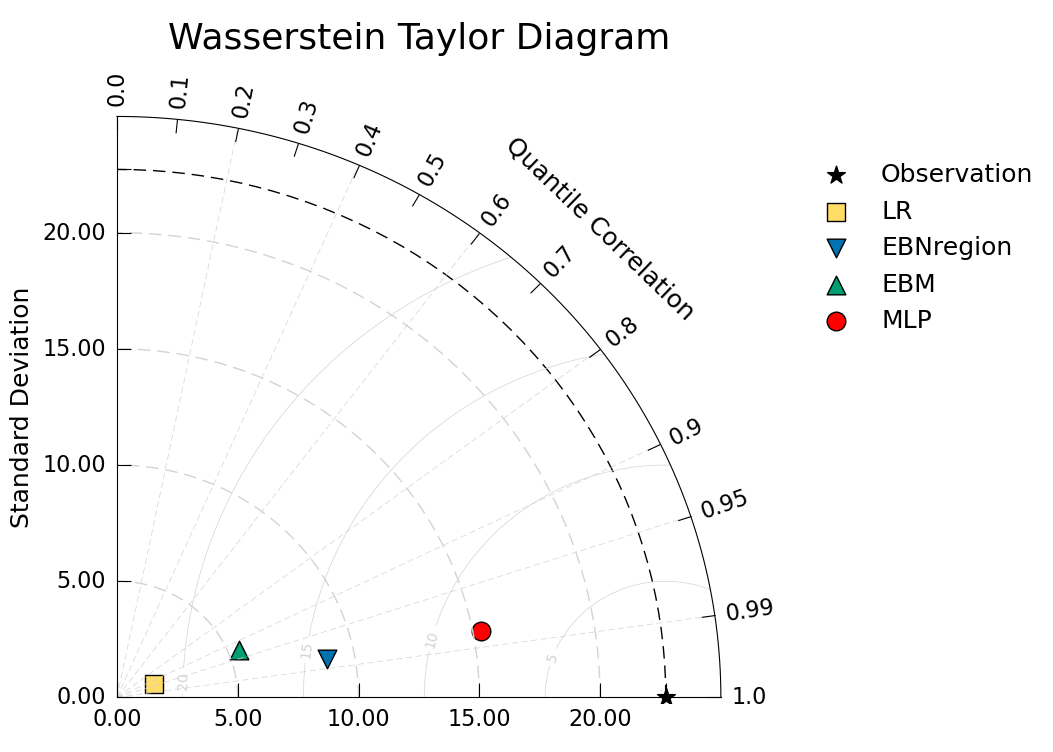

In [7]:
color_1 = (255/255, 0/255, 0/255)     # Pure Red
color_2  = (  0/255, 158/255, 115/255)   # Teal
color_3 = (0/255, 114/255, 178/255)   # Scientific Blue 
color_4  = (255/255, 221/255, 102/255)   # Soft Yellow
color_5  = (148/255,   0/255, 211/255)   # Dark Violet

color_6  = ( 86/255, 180/255, 233/255)   # Sky Blue
color_7  = (230/255, 159/255,   0/255)   # Orange Yellow
color_8 = (102/255, 51/255, 153/255)  # Deep Purple
color_9 = (139/255, 69/255, 19/255)   # Saddle Brown
color_10 = (180/255, 30/255, 90/255)   # Deep Rose
ground_truth_std = np.std(obs, ddof=0)

std_range_tuple = (0, 25)
# std_val_list = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
std_val_list = np.arange(0, 25, 5, dtype=float)

## Create basic figure and Taylor Diagram instance:
fig = plt.figure(figsize=(8, 8))

taylor = gv.TaylorDiagram( refstd=ground_truth_std
                         , fig=fig
                         , label=''
                         , std_range=std_range_tuple
                         , std_level=np.insert(std_val_list
                         , np.searchsorted(std_val_list, ground_truth_std)
                         , ground_truth_std)
                         )

ax = plt.gca()

## Draw diagonal dashed lines from origin to correlation values
## Also enforces proper X-Y ratio
taylor.add_xgrid(np.array([0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99]))
taylor.add_ygrid(std_val_list)

spec_marker_size = 180

taylor.add_model_set( [prediction_std[0]]
                    , [Quantile_Corr[0]]
                    , label='MLP'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , model_outlier_on=True  # plots models with negative correlations and/or standard deviations at bottom of diagram
                    , color=color_1
                    , marker='o'
                    , facecolors=color_1
                    , edgecolors='k'
                    , linewidth=1
                    , s=spec_marker_size
                    )

taylor.add_model_set( [prediction_std[1]]
                    , [Quantile_Corr[1]]
                    , label='EBM'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color=color_2
                    , marker='^'
                    , facecolors=color_2
                    , edgecolors='k'
                    , linewidth=1
                    # , linestyle='--'
                    , s=spec_marker_size
                    )

taylor.add_model_set( [prediction_std[2]]
                    , [Quantile_Corr[2]]
                    , label='EBNregion'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , model_outlier_on=True  # plots models with negative correlations and/or standard deviations at bottom of diagram
                    , color=color_3
                    , marker='v'
                    , facecolors=color_3
                    , edgecolors='k'
                    , linewidth=1
                    , s=spec_marker_size
                    )
taylor.add_model_set( [prediction_std[3]]
                    , [Quantile_Corr[3]]
                    , label='LR'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color=color_4
                    , marker='s'
                    , facecolors=color_4
                    , edgecolors='k'
                    , linewidth=1 
                    , s=spec_marker_size
                    )

taylor.add_model_set( [ground_truth_std]
                    , [1]
                    , label='Observation'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color='black'
                    , marker='*'
                    , facecolors='black'
                    , edgecolors='k'
                    , linewidth=1 
                    , s=spec_marker_size
                    )
#gv.util.set_axes_limits_and_ticks(ax, xlim=[0,2])

# taylor.add_model_name(['MLP', 'EBM', 'LR'], fontsize=16)

## Add figure title
plt.title("Wasserstein Taylor Diagram", size=26, pad=45)

#taylor._ax.axis["left"].label.set_text("Standard Deviation")
taylor._ax.axis["right"].label.set_text("Standard Deviation")
taylor._ax.axis["top"].label.set_text("Quantile Correlation")
taylor._ax.axis["left"].label.set_fontsize(18)
taylor._ax.axis["top"].label.set_fontsize(18)
taylor._ax.axis["right"].label.set_fontsize(18)


#taylor.add_legend(fontsize=10, loc='upper right')
taylor.add_legend(
    fontsize=18,
    loc='upper left',
    bbox_to_anchor=(1.05, 1)
)
## Add constant centered 2-Wasserstein difference contours.
crg = taylor.add_contours( levels=np.arange(0,25,5)
                         , colors='lightgrey'
                         , linewidths=0.5      
                         ).clabel()
# crg.clabel()

# plt.savefig('fig5.pdf', dpi=300, bbox_inches='tight')
